In [9]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import ConcatDataset
# !pip install optuna
# import optuna
import sys
import importlib # Add this line to import the module reloading utility
sys.path.append('/content/')

import nets # Change to import the nets module directly
import train
import data

# Reload the nets module to pick up any changes in nets.py
importlib.reload(nets)
importlib.reload(data)
importlib.reload(train)

# Re-import Net to ensure the updated class is used
from nets import Net
from data import *
from train import *


In [10]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
# torch.use_deterministic_algorithms(True)

set_seed(SEED)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN = False
DATA_FOLDER = "train/"

print(device)

cpu


In [ ]:
# !unzip train.zip
# !unzip test.zip

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
  inflating: test/IMG_383832.JPEG    
  inflating: test/IMG_190687.JPEG    
  inflating: test/IMG_409671.JPEG    
  inflating: test/IMG_167134.JPEG    
  inflating: test/IMG_158908.JPEG    
  inflating: test/IMG_917268.JPEG    
  inflating: test/IMG_373007.JPEG    
  inflating: test/IMG_055156.JPEG    
  inflating: test/IMG_501275.JPEG    
  inflating: test/IMG_041595.JPEG    
  inflating: test/IMG_820292.JPEG    
  inflating: test/IMG_049148.JPEG    
  inflating: test/IMG_372307.JPEG    
  inflating: test/IMG_005061.JPEG    
  inflating: test/IMG_316946.JPEG    
  inflating: test/IMG_139651.JPEG    
  inflating: test/IMG_604304.JPEG    
  inflating: test/IMG_387986.JPEG    
  inflating: test/IMG_268047.JPEG    
  inflating: test/IMG_228670.JPEG    
  inflating: test/IMG_147958.JPEG    
  inflating: test/IMG_730679.JPEG    
  inflating: test/IMG_660727.JPEG    
  inflating: test/IMG_019401.JPEG    
  inflating: test/IMG_3

## Augmentacja danych

In [11]:
normalize_transform = transforms.Normalize((0.5204, 0.4950, 0.4381), (0.2841, 0.2770, 0.2974))

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

### Blur

In [ ]:
transform_blur = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.GaussianBlur(kernel_size=5),
    transforms.ToTensor(),
    normalize_transform,
])

dataset_blur = load_data(data_folder=DATA_FOLDER, transform=transform_blur)
merged_blur_dataset = ConcatDataset([dataset_blur, dataset_blur])
train_dataset_blur, val_dataset_blur = split_dataset(merged_blur_dataset, split_ratio=0.8)
train_loader_blur, val_loader_blur = define_dataloaders(train_dataset_blur, val_dataset_blur, batch_size=32)

net_blur = Net().to(device)
criterion_blur = nn.CrossEntropyLoss()
optimizer_blur = optim.Adam(net_blur.parameters(), lr=0.001)

# print(net_blur)
TRAIN = True
if TRAIN:
    loss_hist_blur, train_eval_hist_blur, val_eval_hist_blur = train_model(net_blur, train_loader_blur, val_loader_blur, criterion_blur, optimizer_blur, get_accuracy, device, 5)
    plot_training_chart(loss_hist_blur, train_eval_hist_blur, val_eval_hist_blur)
    print(train_eval_hist_blur[-1])
    print(val_eval_hist_blur[-1])

Net(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bia

0.24430288956589047
0.23539269990058231


### Cropowanie

In [ ]:
transform_crop = transforms.Compose([
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)),
    transforms.ToTensor(),
    normalize_transform,
])

dataset_crop = load_data(data_folder=DATA_FOLDER, transform=transform_crop)
merged_crop_dataset = ConcatDataset([dataset_crop, dataset_crop])
train_dataset_crop, val_dataset_crop = split_dataset(merged_crop_dataset, split_ratio=0.8)
train_loader_crop, val_loader_crop = define_dataloaders(train_dataset_crop, val_dataset_crop, batch_size=32)

net_crop = Net().to(device)
criterion_crop = nn.CrossEntropyLoss()
optimizer_crop = optim.Adam(net_crop.parameters(), lr=0.001)

print(net_crop)
if TRAIN:
    loss_hist_crop, train_eval_hist_crop, val_eval_hist_crop = train_model(net_crop, train_loader_crop, val_loader_crop, criterion_crop, optimizer_crop, get_accuracy, device, 5)
    plot_training_chart(loss_hist_crop, train_eval_hist_crop, val_eval_hist_crop)
    print(train_eval_hist_crop[-1])
    print(val_eval_hist_crop[-1])

Net(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bia

### Zmiana jasności/saturacji/contrastu...

In [ ]:
transform_color_jitter = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1),
    transforms.ToTensor(),
    normalize_transform,
])

dataset_color_jitter = load_data(data_folder=DATA_FOLDER, transform=transform_color_jitter)
merged_color_jitter_dataset = ConcatDataset([dataset_color_jitter, dataset_color_jitter])
train_dataset_color_jitter, val_dataset_color_jitter = split_dataset(merged_color_jitter_dataset, split_ratio=0.8)
train_loader_color_jitter, val_loader_color_jitter = define_dataloaders(train_dataset_color_jitter, val_dataset_color_jitter, batch_size=32)

net_color_jitter = Net().to(device)
criterion_color_jitter = nn.CrossEntropyLoss()
optimizer_color_jitter = optim.Adam(net_color_jitter.parameters(), lr=0.001)

if TRAIN:
    loss_hist_color_jitter, train_eval_hist_color_jitter, val_eval_hist_color_jitter = train_model(net_color_jitter, train_loader_color_jitter, val_loader_color_jitter, criterion_color_jitter, optimizer_color_jitter, get_accuracy, device, 5)
    plot_training_chart(loss_hist_color_jitter, train_eval_hist_color_jitter, val_eval_hist_color_jitter)

### Obracanie

In [ ]:
transform_rotate = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    normalize_transform,
])

dataset_rotate = load_data(data_folder=DATA_FOLDER, transform=transform_rotate)
merged_rotate_dataset = ConcatDataset([dataset_rotate, dataset_rotate])
train_dataset_rotate, val_dataset_rotate = split_dataset(merged_rotate_dataset, split_ratio=0.8)
train_loader_rotate, val_loader_rotate = define_dataloaders(train_dataset_rotate, val_dataset_rotate, batch_size=32)

net_rotate = Net().to(device)
criterion_rotate = nn.CrossEntropyLoss()
optimizer_rotate = optim.Adam(net_rotate.parameters(), lr=0.001)

if TRAIN:
    loss_hist_rotate, train_eval_hist_rotate, val_eval_hist_rotate = train_model(net_rotate, train_loader_rotate, val_loader_rotate, criterion_rotate, optimizer_rotate, get_accuracy, device, 5)
    plot_training_chart(loss_hist_rotate, train_eval_hist_rotate, val_eval_hist_rotate)

### Wymazywanie

In [ ]:
transform_erase = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
    normalize_transform,
])

dataset_erase = load_data(data_folder=DATA_FOLDER, transform=transform_erase)
merged_erase_dataset = ConcatDataset([dataset_erase, dataset_erase])
train_dataset_erase, val_dataset_erase = split_dataset(merged_erase_dataset, split_ratio=0.8)
train_loader_erase, val_loader_erase = define_dataloaders(train_dataset_erase, val_dataset_erase, batch_size=32)

net_erase = Net().to(device)
criterion_erase = nn.CrossEntropyLoss()
optimizer_erase = optim.Adam(net_erase.parameters(), lr=0.001)

if TRAIN:
    loss_hist_erase, train_eval_hist_erase, val_eval_hist_erase = train_model(net_erase, train_loader_erase, val_loader_erase, criterion_erase, optimizer_erase, get_accuracy, device, 5)
    plot_training_chart(loss_hist_erase, train_eval_hist_erase, val_eval_hist_erase)

## Final


In [12]:
print(device)

cpu


 40%|████      | 4/10 [54:50<1:05:34, 655.82s/it, loss=2.601, train_acc=0.290, val_acc=0.297]

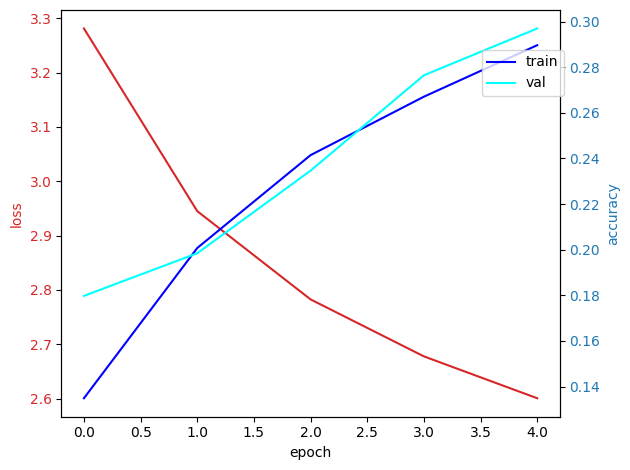

 90%|█████████ | 9/10 [1:49:29<10:55, 655.50s/it, loss=2.361, train_acc=0.351, val_acc=0.324]

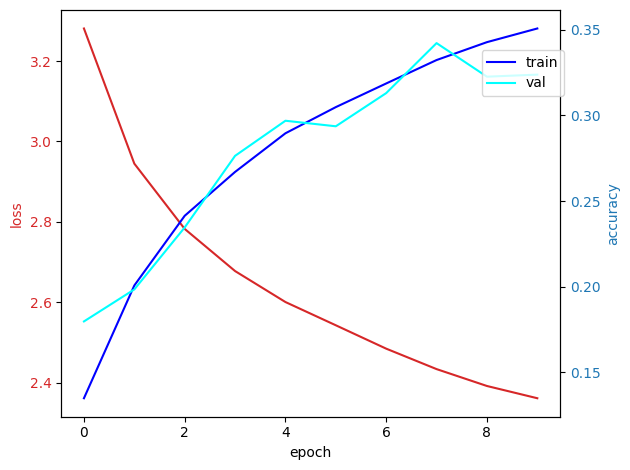

100%|██████████| 10/10 [1:49:29<00:00, 656.94s/it, loss=2.361, train_acc=0.351, val_acc=0.324]


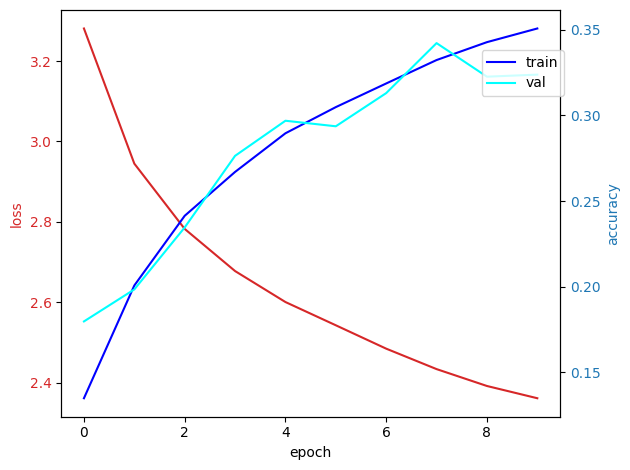

0.35081240768094535
0.32386525024143614


In [13]:
transform_final = transforms.Compose([
    # transforms.Resize((64, 64)),
    transforms.RandomResizedCrop(64, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    normalize_transform,
])

dataset_final = load_data(data_folder=DATA_FOLDER, transform=transform_final)
# merged_final_dataset = ConcatDataset([dataset_final, dataset_final])
merged_final_dataset = dataset_final
train_dataset_final, val_dataset_final = split_dataset(merged_final_dataset, split_ratio=0.8)
train_loader_final, val_loader_final = define_dataloaders(train_dataset_final, val_dataset_final, batch_size=128)

net_final = Net(num_classes=50).to(device)
criterion_final = nn.CrossEntropyLoss()
optimizer_final = optim.Adam(net_final.parameters(), lr=0.001)

TRAIN = True
if TRAIN:
    loss_hist_final, train_eval_hist_final, val_eval_hist_final = train_model(net_final, train_loader_final, val_loader_final, criterion_final, optimizer_final, get_accuracy, device, 10, verbose=True)
    plot_training_chart(loss_hist_final, train_eval_hist_final, val_eval_hist_final)
    print(train_eval_hist_final[-1])
    print(val_eval_hist_final[-1])

In [ ]:
# 0.37
# 0.37
# loss0 = 1.5
# loss_last = 1.41

# Dostrajanie hiperparametrów

In [ ]:
# Łączenie wszystkich transformacji w jeden zbiór danych
clean_dataset = load_data(data_folder=DATA_FOLDER)
dataset_all_transforms = ConcatDataset([dataset_blur, dataset_crop, dataset_color_jitter, dataset_rotate, dataset_erase])

# Wartości do sprawdzenia
kernel_sizes = [[3, 5, 7], [3, 3, 3], [5, 5, 5], [7, 7, 7]]
n_channels = [16, 32, 64]
hidden_sizes = [32, 64, 128]

In [ ]:
def objective(trial):
    ks = trial.suggest_categorical("kernel_sizes", kernel_sizes)
    nc = trial.suggest_categorical("n_channels", n_channels)
    hs = trial.suggest_categorical("hidden_sizes", hidden_sizes)

    print(f"Testing with kernel_sizes={ks}, n_channels={nc}, hidden_size={hs}")
    net = Net(kernel_sizes=ks, n_channels=nc, hidden_size=hs).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)

    train_loader = DataLoader(dataset_all_transforms, batch_size=32, shuffle=True, num_workers=2)
    val, test = split_dataset(clean_dataset, split_ratio=0.5)
    val_loader, test_loader = define_dataloaders(val, test, batch_size=32)

    train_model(net, train_loader, val_loader, criterion, optimizer, get_accuracy, device, 5)

    return get_accuracy(net, test_loader, device)


In [ ]:
print(device)

cuda


In [ ]:
opt = optuna.create_study(direction="maximize")
opt.optimize(objective, n_trials=10)

print(opt.best_params)
print(opt.best_value)

[I 2026-04-16 15:33:25,552] A new study created in memory with name: no-name-07d476d6-294f-4a81-b6cc-d1afc00a20b5
/tmp/ipykernel_5483/2981565737.py:2: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [3, 5, 7] which is of type list.
  ks = trial.suggest_categorical("kernel_sizes", kernel_sizes)
/tmp/ipykernel_5483/2981565737.py:2: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [3, 3, 3] which is of type list.
  ks = trial.suggest_categorical("kernel_sizes", kernel_sizes)
/tmp/ipykernel_5483/2981565737.py:2: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [5, 5, 5] which is of type list.
  ks = trial.suggest_categorical("kernel_sizes", kernel_sizes)
/tmp/ipykernel_5483/2981565737.py:2: UserWarning: Choices for a cat

Testing with kernel_sizes=[7, 7, 7], n_channels=16, hidden_size=64


  0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/5 [01:08<?, ?it/s]
[W 2026-04-16 15:34:34,256] Trial 0 failed with parameters: {'kernel_sizes': [7, 7, 7], 'n_channels': 16, 'hidden_sizes': 64} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_5483/2981565737.py", line 15, in objectiv

KeyboardInterrupt: 

In [ ]:
  # transform = transforms.Compose([transforms.ToTensor()])
  # trainset = torchvision.datasets.CIFAR10(root='./train', train=True,
  #                                         download=True, transform=transform)
  # testset = torchvision.datasets.CIFAR10(root='./train', train=False,
  #                                       download=True, transform=transform)

  # sample = trainset[4]
  # print(f"PIL -> Tensor: shape={sample[0].shape} | dtype={sample[0].dtype} | min={sample[0].min()} | max={sample[0].max()}")

  # all_samples = torch.stack([sample[0] for sample in trainset])
  # print(f"Data norm: mean={all_samples.mean():.4f} | std={all_samples.std():.4f}")
  # print(f"Data norm per channel: mean={all_samples.mean(axis=(0,2,3))} | std={all_samples.std(axis=(0,2,3))}")


In [ ]:
def Check_Accuracy_On_Whole_Dataset(model):
  model.to(device)
  model.eval()

  transforms_whole = transforms.Compose([
      transforms.Resize((64, 64)),
      transforms.ToTensor(),
      normalize_transform,
  ])
  dataset = load_data(data_folder=DATA_FOLDER, transform=transforms_whole)
  train_dataset, val_dataset = split_dataset(dataset, split_ratio=1.0)
  train_loader, val_loader = define_dataloaders(train_dataset, val_dataset, batch_size=128)

  return get_accuracy(model, train_loader, device)


In [ ]:
print(Check_Accuracy_On_Whole_Dataset(model=net_final))

0.360500391996455


In [ ]:
import os
from PIL import Image
import torch
from torchvision import transforms


def predict_to_csv(model, image_dir="test", output_csv="pred.csv", device="cuda"):
    """
    Runs inference on all images in a folder and saves predictions to CSV.

    Args:
        model: trained PyTorch model
        image_dir (str): folder containing images
        output_csv (str): path to save predictions
        device (str): 'cuda' or 'cpu'
    """

    model.to(device)
    model.eval()

    # Adjust this transform to match your training preprocessing!
    transform = transforms.Compose([
        transforms.Resize((64, 64)),  # change if needed
        transforms.ToTensor(),
        # optionally add normalization if used during training:
        normalize_transform,
        # transforms.Normalize(mean=[0.485, 0.456, 0.406],
        #                      std=[0.229, 0.224, 0.225]),
    ])

    # collect image paths
    image_files = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpeg", ".jpg", ".png"))
    ]

    # sort for deterministic output
    image_files.sort()

    predictions = []

    with torch.no_grad():
        for fname in image_files:
            path = os.path.join(image_dir, fname)

            image = Image.open(path).convert("RGB")
            image = transform(image).unsqueeze(0).to(device)

            outputs = model(image)
            pred_class = outputs.argmax(dim=1).item()

            predictions.append((fname, pred_class))

    # write CSV
    with open(output_csv, "w") as f:
        for fname, pred in predictions:
            f.write(f"{fname},{pred}\n")

    print(f"Saved {len(predictions)} predictions to {output_csv}")

In [ ]:
predict_to_csv(net_final, image_dir="test", output_csv="pred.csv", device=device)

Saved 10000 predictions to pred_36%_Sprawdzone.csv
